# UK Biobank — Academic Impact: the assembled panels

**What this notebook is.** The one place analysis 03's figures are *selected* and
*assembled*, on the model of
[`04_non_academic_99_all.ipynb`](04_non_academic_99_all.ipynb). The two source notebooks
stay as they are — they are where the data work and the diagnostics live — and this
notebook re-draws the charts that made the cut into one main-paper panel and three
supplementary panels.

| source notebook | charts | arm |
|---|---|---|
| [`03_academic_impact_01_for_analysis.ipynb`](03_academic_impact_01_for_analysis.ipynb) | 11 | volume, activity index, citation impact, quality bands, growth — by **field** |
| [`03_academic_impact_02_citation.ipynb`](03_academic_impact_02_citation.ipynb) | 3 | entry cohorts, impact portfolios, influence fingerprint — by **author** |

## The argument the figures make

Analysis 01 owns UK Biobank's *output*. This one owns its **position relative to the rest
of the literature**, which is the only thing the two-arm design can say and nothing else
in the project can. Every panel is a ratio against the whole database:

> what UK Biobank is disproportionately **about** (A) · where that work **lands** (B) ·
> how much of each field's **best** work is its (C) · how its footprint splits at each
> field's own bars (D) · and **who** produced it (E).

**The size fact that governs every reading.** UK Biobank is **0.044%** of the tagged
literature over 2015–2025. A *share* of a field is therefore small everywhere by
construction and mostly reproduces "which fields are big", which is why panel A leads
with the activity index rather than a share, and why none of the volume charts made the
cut.

## Re-drawn, not pasted

Same rule as 04 (D28). Every panel is re-drawn from the data through `draw_<name>(ax, D)`
functions in
[`data_analysis_03_academic_impact_panels.py`](../utils/data_analysis_03_academic_impact_panels.py),
into a figure this notebook has already sized, under one style section — never by pasting
saved images. **Nothing has to be on disk for that**, which is why §1 is an inventory and
not a gate: the field notebook inherits `save: false` and writes none of its 11 charts.

The palette is `shared_style.PALETTE_COLORS` — **the same seven named colours analysis 04
is drawn in** (D29), so the two figure families belong to one paper. Where a chart needs
more than seven categories or an ordered ramp, it is derived from those anchors rather
than reaching for a new hue.

## The selection

Decided with the project owner on **2026-09-09**, against all 14 charts. Unlike 04, this
selection **does** discard: six charts are in neither the main figure nor the SI, and §3
records the reason per chart rather than leaving it implicit.

| figure | panels | contents |
|---|---|---|
| **Main** | A–D | impact map (2×2) · activity index · top-decile share · the footprint cut twice, a 2×4 field block spanning the page |
| **SI 1** | — | the impact map at 25 fields, every point labelled |
| **SI 2** | A–B | growth, not size: rates, and the trajectories behind them |
| **SI 3** | A–C | the author arm: entry cohorts, portfolio map, influence fingerprint |

## Naming

Per **D30**, the pages are named by the `01_growth` scheme —
`03_01_figure_01_…` for the main figure and `03_02_supplementary_figure_01_…` onwards for
the SI — not by the role-based scheme 04 originally used and has since been renamed off.

## 1. Setup

The style section is `03_academic_impact_99_all` — the seven-colour palette that
`shared_style.PALETTE_COLORS` names, dashed gridlines on both axes and both tick levels,
and `save: true` writing pdf + svg + png at dpi 600 into
`output/figures/data_analysis/03_academic_impact/`.

§1's inventory is **informational**. The author arm's three figures are on disk because
its notebook sets `save = True`; the field arm's eleven are not, because it inherits
`save: false`. Neither fact affects anything below.

In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched from
# (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# The panel module is edited while this notebook stays open; without autoreload a
# re-run of a figure cell silently reuses the function imported at kernel start.
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from utils.shared_style import PALETTE_COLORS, load_style
from utils import data_analysis_03_academic_impact_panels as NP

STYLE = load_style("03_academic_impact_99_all")

FIG_DIR = Path(STYLE["savedir"])
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("palette :", ", ".join(f"{k}={v}" for k, v in PALETTE_COLORS.items()))
print("figures :", P.raw_path(FIG_DIR), "|", ", ".join(STYLE["formats"]),
      "at dpi", STYLE["dpi"])
print("tables  :", P.raw_path(TABLE_DIR))
print("grid    :", STYLE["grid_linestyle"], "on both axes, major and minor")

_on_disk = sorted({f.stem for f in FIG_DIR.glob("*.*")
                   if f.suffix.lower() in {".pdf", ".png"}})
print(f"\n{len(_on_disk)} figure stem(s) already under that directory "
      f"(informational — the assembly re-draws and reads none of them):")
for stem in _on_disk:
    print("   ", stem)

palette : red=#E66859, cream=#FEE7BA, light_blue=#75BBD4, blue=#74ADD1, steel_blue=#416FA0, navy=#274668, green=#74D1AF
figures : output/figures/data_analysis/03_academic_impact | pdf, png at dpi 600
tables  : output/tables/03_academic_impact
grid    : -- on both axes, major and minor

7 figure stem(s) already under that directory (informational — the assembly re-draws and reads none of them):
    03_01_figure_01_academic_impact
    03_02_supplementary_figure_01_impact_map_full
    03_03_supplementary_figure_02_growth
    03_04_supplementary_figure_03_author_arm
    fig3a_author_entry_cohort_academic_impact_profile
    fig_author_impact_portfolio_map
    fig_author_influence_fingerprint_heatmap


## 2. Build the aggregates — once, from both arms

Roughly 20 seconds: `AI.build` loads the two count arms off the API pathway, then the
measured cut-off tables and the author arm's two written tables. Everything the panels
draw comes out of this one dict, so a figure cannot quietly read a different vintage of
the data than its neighbour.

**The author arm is read, not rebuilt.** Its tables come from
`03_academic_impact_02_citation.ipynb`, which is the notebook responsible for them;
rebuilding here would mean re-exploding 267,571 author slots out of the corpus parquet to
reproduce a file that already exists. The paper-level table is 62 MB and is read six
columns wide rather than twenty-four.

`assert_parameters_match()` then checks the loaded run against this module's constants —
they are copied from the field notebook's §2 rather than imported, because a notebook
cannot be imported, so the tripwire is what stops the two drifting.

In [2]:
D = NP.build_panel_data()
NP.assert_parameters_match(D)
print("\nparameters match the loaded run.")

loading both arms from data/analysis/academic_impact/for_counts_api (API pathway) …
loading for partials from /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 613 rows, 113 fields, blank labels 0.0%
  background 1 partial(s), 3,762 rows, 171 fields, blank labels 0.0%
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10f, n_top10f_docs, n_top50f, n_top50f_docs
  citation weights: n_cit, n_top10f, n_top50f, n_mncs
  no relative ratio for n_cit — not normalised by publication year,


activity index, 2015-2025 — base=within_parent (within its own L2 division):
  field                                    global  within L2
  Epidemiology                               61.4       12.0
  Clinical Sciences                           1.8        0.9
  Genetics                                   18.0        6.2
  Biological Psychology                       8.1        2.4
  Cardiovascular Medicine and Haematolo…      3.9        1.8
  Public Health                               4.8        0.9
  Oncology and Carcinogenesis                 1.6        0.7
  Health Services and Systems                 1.6        0.3

citation weight coverage (share of papers carrying a value):

  n_cit    ukbb 98%-100%   background 100%-100%   usable 2015-2025
  n_top10f ukbb 98%-100%   background 100%-100%   usable 2015-2025
  n_top50f ukbb 98%-100%   background 100%-100%   usable 2015-2025
  n_mncs   ukbb 98%-100%   background 100%-100%   usable 2015-2025

impact window 2015-2025 — the years every

  cut-offs: top decile in 213 cell(s), median in 213


  author arm: 266,131 author-paper rows, 88,662 distinct authors
  growth: 23 field(s) clear the floors; UK Biobank overall 26%/yr over 2021-2025

UK Biobank is 0.044% of the whole database over 2015-2025 (n_papers).
done.

parameters match the loaded run.


### What the two arms actually contain

Printed rather than remembered — these are the numbers the panels are drawn on, and they
are the rows to check against `doc/STATE.md` §2 before quoting anything from the figures.

In [3]:
print(f"analysis window      {NP.ANALYSIS_MIN}-{NP.ANALYSIS_MAX}   "
      f"(vocabulary: {D['SYSTEM']} {D['LEVEL']})")
print(f"UK Biobank's share   {D['ukbb_overall_share']:.3f}% of the whole database")
print(f"citation window      {D['CITE_WIN'][0]}-{D['CITE_WIN'][1]}   "
      f"headline {D['CITE_HEADLINE']}")
print(f"measured cut-offs    {int(D['CUTS'].thr10.notna().sum())} (year, field) cells")
print(f"authors              {len(D['author']['summary']):,} distinct\n")

print(f"UK Biobank's top {NP.TOP_N} fields — share, activity index, relative impact:\n")
_head = D["CITE_HEADLINE"][2:]
_rows = []
for code_, lab in zip(D["TOP_CODES"], D["TOP_LABELS"]):
    _rows.append({
        "field": lab,
        "ukbb_papers": int(D["ukbb"][(D["ukbb"].for_label == lab)
                                     & D["ukbb"].year.between(NP.ANALYSIS_MIN,
                                                              NP.ANALYSIS_MAX)]
                           [D["VALUE"]].sum()),
        "activity_x": round(D["ACTIVITY"].get(code_, float("nan")), 2),
        f"rci_{_head}": round(D["IMPACT"].loc[code_, f"rci_{_head}"], 2),
    })
display(pd.DataFrame(_rows))

print("author-entry cohort shares (%):")
display((100 * D["author"]["contrib_share"]).round(1))

analysis window      2015-2025   (vocabulary: Fields of Research (ANZSRC 2020) L4)
UK Biobank's share   0.044% of the whole database
citation window      2015-2025   headline n_mncs
measured cut-offs    213 (year, field) cells
authors              88,662 distinct

UK Biobank's top 8 fields — share, activity index, relative impact:



,field,ukbb_papers,activity_x,rci_mncs
0,Epidemiology,6256,12.00,1.80
1,Clinical Sciences,5458,0.86,2.83
2,Genetics,5321,6.20,2.72
3,Biological Psychology,2244,2.42,2.12
4,Cardiovascular Medicine and Haematology,1904,1.84,4.29
5,Public Health,1864,0.93,3.11
6,Oncology and Carcinogenesis,1359,0.74,1.62
7,Health Services and Systems,1207,0.32,3.04


author-entry cohort shares (%):


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,5.0,19.6,35.8,39.6
Fractional paper credit,18.1,25.6,32.5,23.8
Fractional citation credit,42.8,32.8,20.1,4.3
Top-decile paper credit,24.4,28.3,31.7,15.6
First/last-author credit,18.5,26.5,32.7,22.3


## 3. The selection, on the record

One row per panel: which figure, which letter, and the caption line that goes under it —
plus the charts that are in **neither** figure, with the reason. Written to
`output/tables/03_academic_impact/panel_selection.csv` so the paper draft and this
notebook cannot disagree about which chart is panel D, or about why chart 6 is absent.

**Two debts this selection leaves owing**, both consequences of dropping the quality-band
SI and chart 6:

1. **Chart 9 is now a main-paper panel (D), so its cut-offs need a methods home.** §6.1 of
   the field notebook measures what "top decile" and "above the median" were worth in
   citations per (year, field) — 213 measured L4 cells, the decile landing at 7.30–10.00%
   and the median at 34.23–50.00%. The panel annotations carry the final year's pair, so
   the figure is partly self-documenting, but the full table belongs in the methods
   section as a **table**.
2. **Nothing now shows the impact result surviving the choice of measure.** That was
   chart 6's left panel. `n_mncs`, `n_top10f` and `n_top50f` rank the fields differently
   by construction. Cheapest mitigation: carry all three columns in SI 1's `IMPACT` table
   rather than the headline alone — which the table written below does.

In [4]:
rows = [{"figure": "03_01_figure_01_academic_impact", "panel": letter,
         "caption": caption}
        for letter, caption in NP.MAIN_CAPTION.items()]
_si_stems = {"impact_map": "03_02_supplementary_figure_01_impact_map_full",
             "growth": "03_03_supplementary_figure_02_growth",
             "author_arm": "03_04_supplementary_figure_03_author_arm"}
rows += [{"figure": _si_stems[section], "panel": letter, "caption": caption}
         for section, captions in NP.SI_CAPTIONS.items()
         for letter, caption in captions.items()]

# The charts in NEITHER figure. Recorded here so the reason survives the decision rather
# than living only in a chat log.
EXCLUDED = {
    "chart 1":  "whole-database trends with UK Biobank stacked in. The slice is invisible "
                "in 7 of 8 panels - true, and the point of the 0.044% fact, but it cannot "
                "carry a panel. 01_growth owns output.",
    "chart 2":  "UK Biobank papers per field and share of field. Volume, not position; "
                "01_growth owns it, and panel A divides the size out anyway.",
    "chart 3":  "annual growth speed, the first difference of chart 1. A diagnostic - the "
                "series is dominated by year-to-year sawtooth.",
    "chart 6":  "the measures-agree dot chart and impact over time. Dropped in favour of "
                "chart 7 as the single impact headline; the IMPACT table now has to carry "
                "the measure-robustness result numerically. See the note in section 3.",
    "chart 9a": "chart 9 against the cut-offs themselves on a second axis.",
    "chart 10": "the size of each field's top-decile pool and UK Biobank's share of it.",
    "sec 4.3":  "the marginal annual increase table (before vs after UKBB_YEAR).",
}
rows += [{"figure": "(excluded)", "panel": chart, "caption": why}
         for chart, why in EXCLUDED.items()]

selection = pd.DataFrame(rows)
selection.to_csv(TABLE_DIR / "panel_selection.csv", index=False)
print(f"{len(NP.MAIN_CAPTION)} main panels + "
      f"{sum(len(c) for c in NP.SI_CAPTIONS.values())} SI panels + "
      f"{len(EXCLUDED)} excluded charts -> "
      f"{P.raw_path(TABLE_DIR / 'panel_selection.csv')}\n")
display(selection)

4 main panels + 6 SI panels + 7 excluded charts -> output/tables/03_academic_impact/panel_selection.csv



,figure,panel,caption
0,03_01_figure_01_academic_impact,A,Where UK Biobank concentrates against where th...
1,03_01_figure_01_academic_impact,B,"A's horizontal axis on its own, ranked: what U..."
2,03_01_figure_01_academic_impact,C,"A's vertical question over time, at the sharp ..."
3,03_01_figure_01_academic_impact,D,The footprint cut twice. UK Biobank's share of...
4,03_02_supplementary_figure_01_impact_map_full,A,The impact map at UK Biobank's 25 largest fiel...
5,03_03_supplementary_figure_02_growth,A,"Compound annual growth 2021–2025 by field, UK ..."
6,03_03_supplementary_figure_02_growth,B,The absolute trajectories those rates summaris...
7,03_04_supplementary_figure_03_author_arm,A,"Who produced the work. Share of authors, fract..."
8,03_04_supplementary_figure_03_author_arm,B,"Author output against field-normalised impact,..."
9,03_04_supplementary_figure_03_author_arm,C,What each leading contributor is ahead on. Col...


## 4. The main-paper panel

Four lettered panels on a three-column grid:

```text
+---------------------------+-----------+
|                           |     B     |   A  impact map        (2 rows x 2 cols)
|             A             +-----------+   B  activity index    (top right)
|                           |     C     |   C  top-decile share  (below it)
+---------------------------------------+
|                     D                 |   D  the footprint block, full width
+---------------------------------------+
```

**The impact map leads and takes the largest slot.** It is the one panel carrying both
questions at once — how much UK Biobank publishes in a field, and how well that work is
cited there — so the two panels beside it read as its margins: **B** is its horizontal
axis on its own, ranked; **C** is its vertical question over time, at the sharp end.
**D** then puts the quality claim back into each field's own citation distribution across
eight fields, which is why it needs the full width.

Reading notes worth carrying into the caption:

* **A**'s solid rule is UK Biobank's **own** average impact, not world parity. Against the
  world essentially every field is above 1×, so that line tells nothing apart. Its
  horizontal axis is measured `within_parent` — each L4 field against its own L2 division
  — which is what removes "UK Biobank is a biomedical resource" from the comparison.
  Epidemiology reads **12.0×** its own division and **61.4×** against all research; the
  gap between those two numbers is why the notebook defaults to the former.
* **B** is cut to 10 fields and **C**'s labels to 14 characters: both sit in one column of
  three, and the same charts at full width carry 20 and 22.
* **C** and **D** share a numerator and differ in denominator, and they are not the same
  number. C divides by the **field's** top-decile papers ("how much of this field's best
  work is UK Biobank's", 7.3% for Epidemiology in 2025); D's solid band divides by **all**
  the field's papers; D's in-panel % divides by **UK Biobank's own** papers in the field.
  Two of them being close in a given year is a coincidence, not a cross-check.
* **D no longer states its own cut-offs.** Each sub-panel used to carry a grey line giving
  what the two bars were worth in citations that year; it was removed on 2026-09-09 to
  leave the bands uncluttered. §4.1 writes those numbers to a table instead, and **the
  methods section now has to carry it** — without it the figure does not say whether a
  median band means "above the median" or "cited at all".

**Panel E is gone from this page.** The author-entry cohort profile moved to SI 3 when the
page went to three columns; it is a result, not a casualty, and SI 3 is the figure the
rest of the author arm already lives in.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_01_figure_01_academic_impact.pdf


saved output/figures/data_analysis/03_academic_impact/03_01_figure_01_academic_impact.png


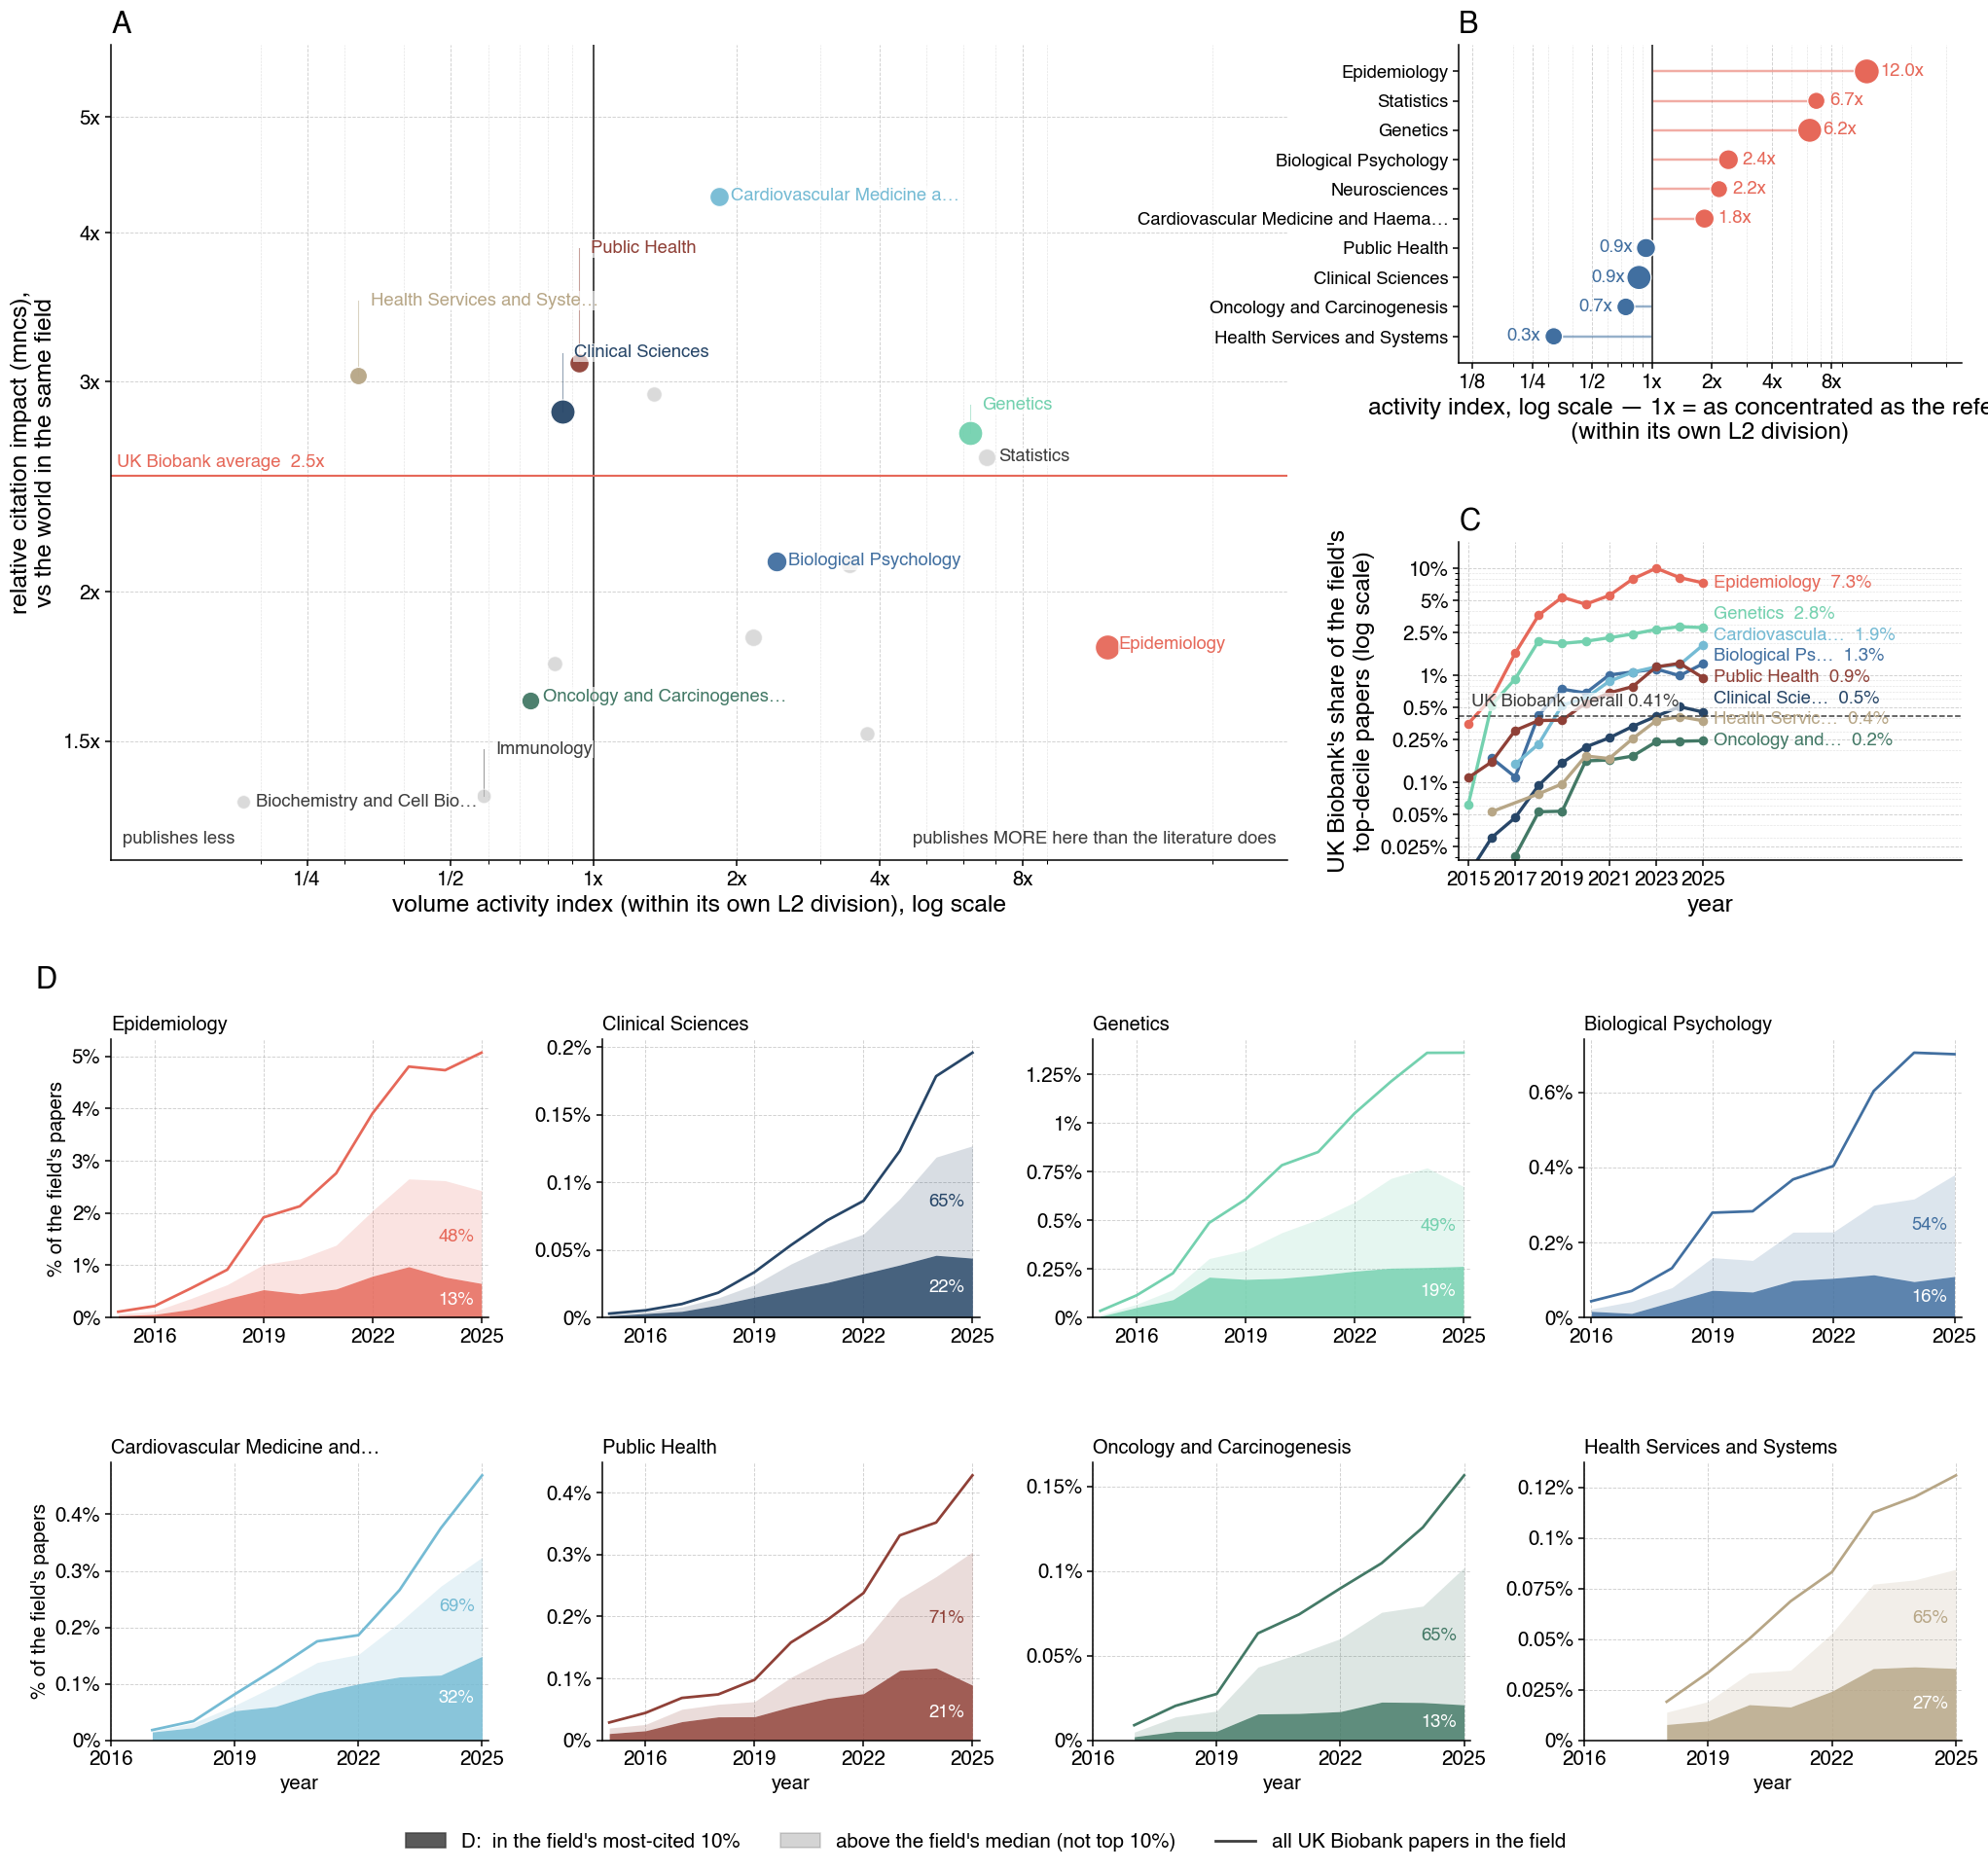

In [5]:
fig_main = NP.figure_main(D)

### 4.1 What panel D's bars were worth, in citations *(for the methods section)*

Panel D cuts each field's footprint at that field's own top decile and median. Both
cut-offs are **measured** per (year, field) by binary search against the live index, not
interpolated — and both fall steeply with publication year because citations accrue:
2015's tenth-best Epidemiology paper needed 63 citations, 2025's needs 8. That is the
clock, not a decline in standards, and it is exactly why the cut is taken per year.

**Read `median_achieved_pct` before quoting a median band.** Citations are small integers
with enormous ties, so in a recent year the cut lands at "≥ 1 citation" and keeps as
little as 34% of the field. The count above the cut is still exact; what is approximate is
calling it the 50th percentile.

The table holds the cells **panel D draws** — the eight fields, inside the window, where
the decile was actually measured. That is a subset of the **213** measured L4 cells across
all 113 fields, over which the decile lands at 7.30–10.00% (median 9.77%) and the median
at 34.23–50.00% (median 47.69%).

In [6]:
cuts = NP.cut_off_table(D)
cuts.to_csv(TABLE_DIR / "panel_d_citation_cutoffs.csv", index=False)
print(f"{len(cuts)} measured (year, field) cells -> "
      f"{P.raw_path(TABLE_DIR / 'panel_d_citation_cutoffs.csv')}\n")

_m = cuts.dropna(subset=["median_achieved_pct"])
print(f"top-decile cut achieved  {cuts.top_decile_cites.notna().sum()} cells")
print(f"median cut achieved      {_m.median_achieved_pct.min():.2f}% - "
      f"{_m.median_achieved_pct.max():.2f}%  (median {_m.median_achieved_pct.median():.2f}%); "
      f"{int((_m.median_achieved_pct < 45).sum())} cells more than five points short\n")

# The final year for each field, which is what the panels' sharp end shows.
display(cuts[cuts.year == NP.ANALYSIS_MAX]
        .set_index("field")[["top_decile_cites", "median_cites", "mean_cites",
                             "median_achieved_pct"]])

81 measured (year, field) cells -> output/tables/03_academic_impact/panel_d_citation_cutoffs.csv

top-decile cut achieved  81 cells
median cut achieved      34.77% - 50.00%  (median 48.13%); 12 cells more than five points short



,top_decile_cites,median_cites,mean_cites,median_achieved_pct
field,,,,
Biological Psychology,7.0,1.0,2.21,49.03
Cardiovascular Medicine and Haematology,5.0,1.0,1.45,34.77
Clinical Sciences,5.0,1.0,1.69,41.76
Epidemiology,8.0,2.0,2.90,39.06
Genetics,7.0,2.0,2.60,38.00
Health Services and Systems,5.0,1.0,1.72,42.34
Oncology and Carcinogenesis,8.0,1.0,2.67,48.24
Public Health,6.0,1.0,2.09,48.44


## 5. SI 1 — The impact map at 25 fields

Main-figure panel B carries UK Biobank's 16 largest fields and labels the top eight plus
whatever is extreme on either axis. This is the same map undrawn-down: 25 fields, every
one labelled, at full page.

The `IMPACT` table beneath it is the numbers behind both versions, and it carries **every**
weight that takes a ratio rather than only the headline — which is where the
measure-robustness result now lives, chart 6 having been dropped (§3).

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.pdf


saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.png
25 fields x 8 measures -> output/tables/03_academic_impact/si1_impact_table_all_weights.csv



,ukbb_papers,activity_x,rci_top10f,act_top10f,rci_top50f,act_top50f,rci_mncs,act_mncs
field,,,,,,,,
Epidemiology,6256.0,12.003,1.965,12.902,1.134,14.367,1.797,44.029
Clinical Sciences,5458.0,0.859,3.118,0.617,1.477,0.563,2.832,2.090
Genetics,5321.0,6.201,2.484,4.774,1.196,4.433,2.719,19.496
Biological Psychology,2244.0,2.420,2.064,1.926,1.104,1.986,2.123,6.854
Cardiovascular Medicine and Haematology,1904.0,1.835,4.302,2.135,1.677,1.605,4.289,6.758
Public Health,1864.0,0.932,3.231,1.647,1.453,1.428,3.111,5.918
Oncology and Carcinogenesis,1359.0,0.738,1.946,0.382,1.370,0.518,1.624,1.029
Health Services and Systems,1207.0,0.320,3.080,0.604,1.392,0.526,3.037,1.985
Statistics,1136.0,6.695,2.088,2.229,1.230,2.532,2.594,8.838


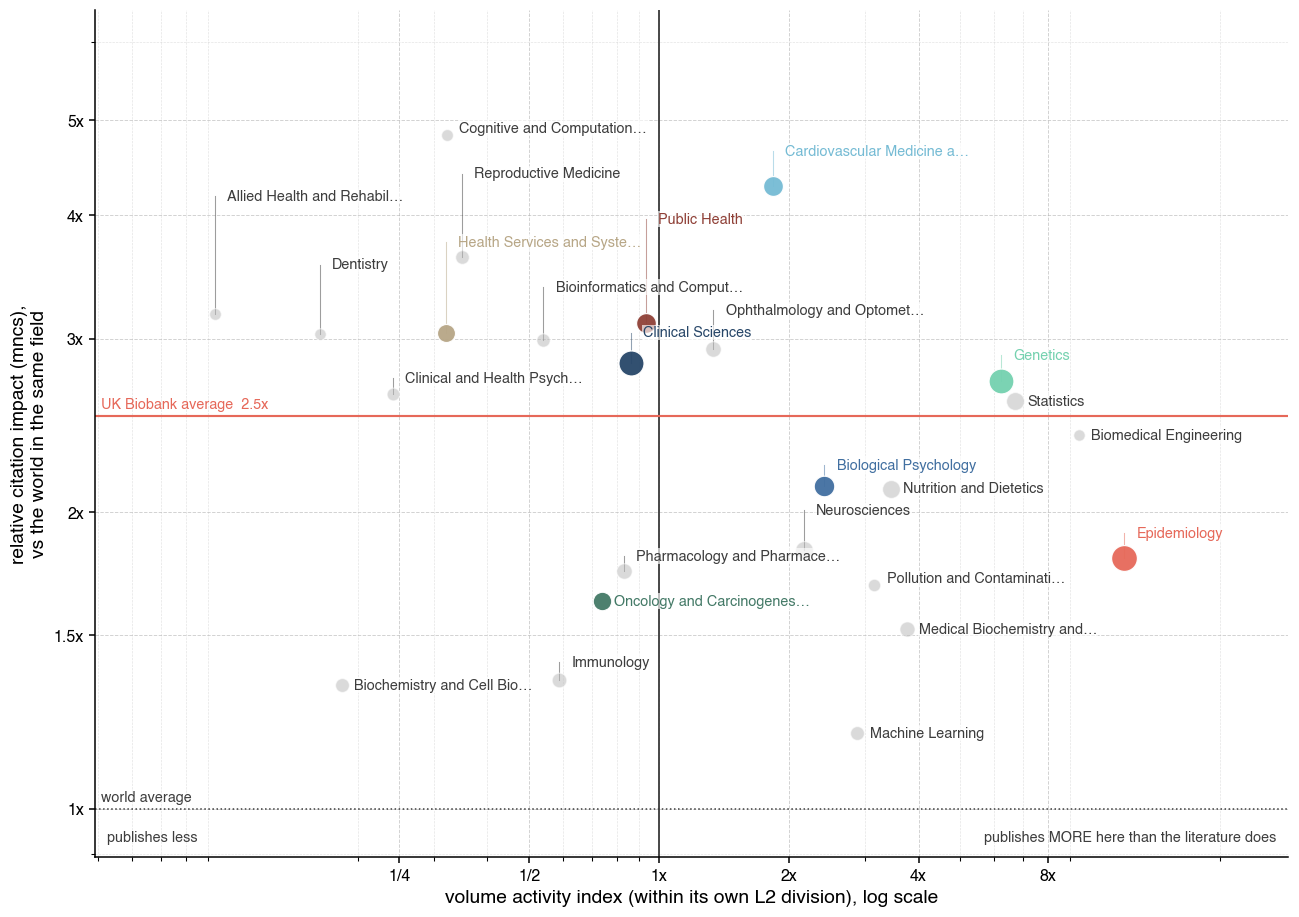

In [7]:
fig_si1 = NP.figure_si_impact_map(D)

# Every rci_ weight, not just the headline: with chart 6 out of the figure set, this
# table is the only place the reader can see whether a field's ranking survives the
# choice of measure.
_cols = ["ukbb_papers", "activity_x"] + [c for c in D["IMPACT"].columns
                                         if c.startswith(("rci_", "act_"))]
impact_out = (D["IMPACT"][_cols]
              .assign(field=[D["label_of"](c) for c in D["IMPACT"].index])
              .set_index("field")
              .nlargest(NP.MAP_M_SI, "ukbb_papers")
              .round(3))
impact_out.to_csv(TABLE_DIR / "si1_impact_table_all_weights.csv")
print(f"{len(impact_out)} fields x {len(_cols)} measures -> "
      f"{P.raw_path(TABLE_DIR / 'si1_impact_table_all_weights.csv')}\n")
display(impact_out)

## 6. SI 2 — Growth, not size

Every other panel in this family ranks fields by size, which is stable by construction —
Epidemiology and Clinical Sciences were the biggest in 2016 and will be in 2026 — so it
cannot show a field *arriving*. This ranks by speed and drops the size filter.

It is in the SI rather than the main figure because it answers a **growth** question
inside an impact analysis, and analysis 01 owns growth. It is kept because the result is
not available anywhere else: the hollow marker is the same field's growth in the whole
database, so the gap between the markers is UK Biobank **moving into** a field rather than
the field itself taking off. Neurosciences is the sharpest case — the world's output is
flat (−0.2%/yr) while UK Biobank's grows 47%/yr.

Read the acceleration column knowing UK Biobank's own output was doubling annually in the
late 2010s from a base of almost nothing, so nearly every field decelerates against that
window. The number says "growing less explosively than during the ramp-up", not
"shrinking".

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_growth.pdf


saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_growth.png
UK Biobank overall grew 26%/yr over 2021-2025



,ukbb@2025,ukbb_%/yr,ukbb_accel_pp,world_%/yr,activity_x
label,,,,,
Medical Biochemistry and Metabolomics,200.0,73.6,-8.5,12.6,3.8
Biomedical Engineering,35.0,62.7,13.1,7.4,9.4
Biochemistry and Cell Biology,112.0,57.9,NaN,2.2,0.2
Clinical and Health Psychology,49.0,42.2,23.2,6.2,0.2
Neurosciences,329.0,39.9,-54.7,2.2,2.2
Cognitive and Computational Psychology,39.0,37.2,-15.9,5.1,0.3
Ophthalmology and Optometry,159.0,37.1,-46.0,2.4,1.3
Nutrition and Dietetics,308.0,34.9,-18.0,6.0,3.4
Bioinformatics and Computational Biology,66.0,34.8,-43.0,0.9,0.5


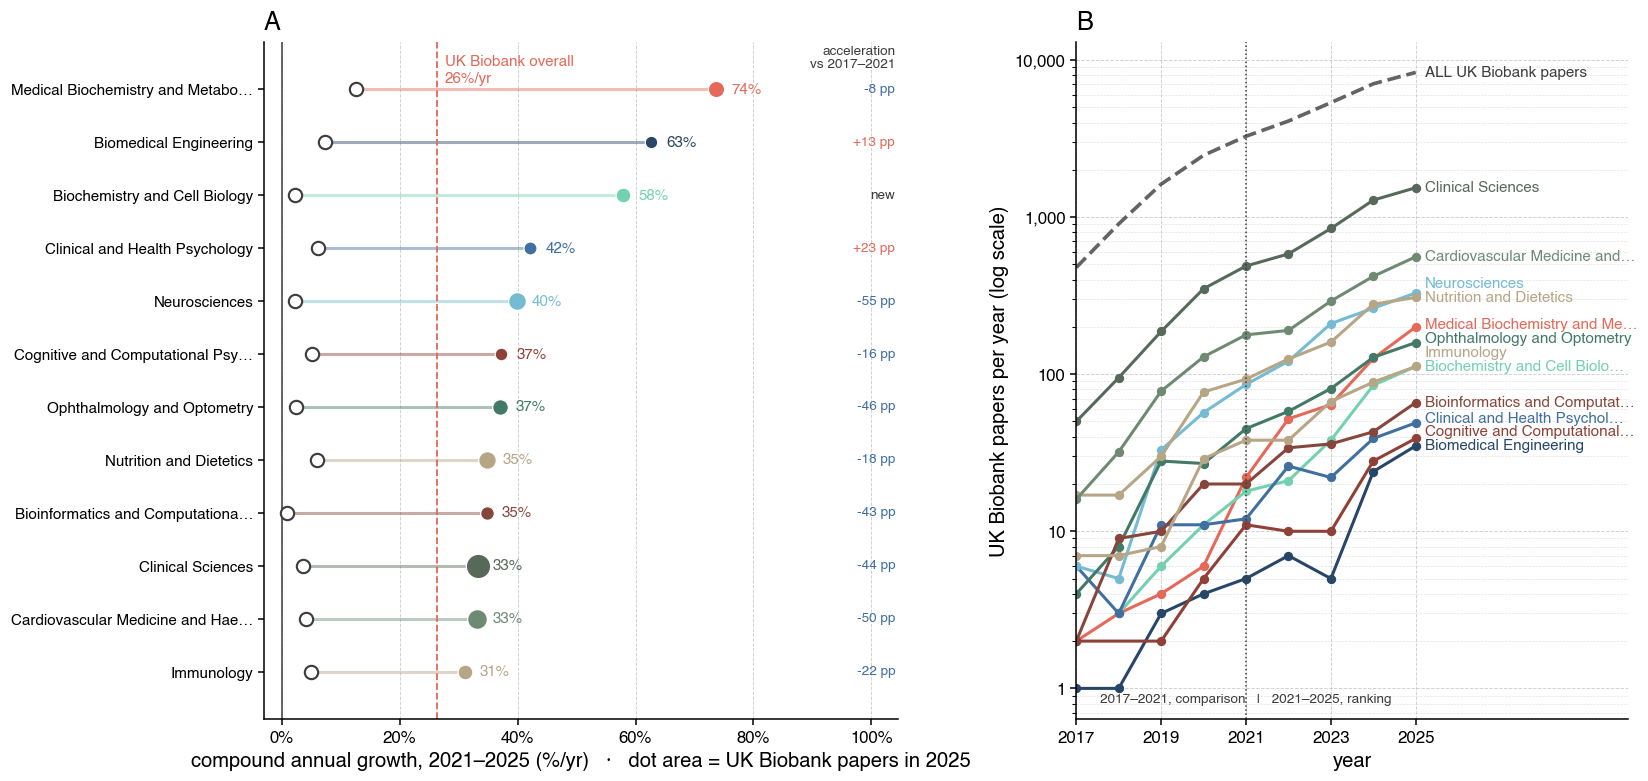

In [8]:
fig_si2 = NP.figure_si_growth(D)

growth_out = (D["GROWTH"].head(NP.GROW_TOP_M)
              .set_index("label")[["ukbb_papers", "ukbb_now", "accel",
                                   "world_now", "activity_x"]]
              .rename(columns={"ukbb_papers": f"ukbb@{NP.GROW_NOW[1]}",
                               "ukbb_now": "ukbb_%/yr", "accel": "ukbb_accel_pp",
                               "world_now": "world_%/yr"})
              .round(1))
growth_out.to_csv(TABLE_DIR / "si2_fastest_growing_fields.csv")
print(f"UK Biobank overall grew {D['UKBB_PACE']:.0f}%/yr over "
      f"{NP.GROW_NOW[0]}-{NP.GROW_NOW[1]}\n")
display(growth_out)

## 7. SI 3 — The author arm

Three panels. **A** was the main page's panel E until the page went to three columns on
2026-09-09; it comes here rather than being dropped, because the 2021–23 cohort holding
the largest share of top-decile credit is a result and this is the figure the rest of the
author arm already lives in.

**A** groups authors by the year of their first paper in the corpus. Read the top-decile
row against its own history: under the pooled cut-off this arm used before the D21
reconcile, that row was substantially a measure of paper age and the earliest cohort
dominated it by construction. It is now the measured per-(year, field) decile, so a 2024
paper is judged against 2024's bar.

**B** is every author with at least five papers in the window — 11,022 of them — plotted
as output against field-normalised impact. Colour is the share of those papers on which
they were first or last author, so the dark points are the researchers leading the work
rather than joining large consortia, and the pale mass at the top right is the
consortium-authorship pattern that dominates genetics.

**C** names individuals. It is a leaderboard's honest form: a single rank hides that the
leading contributors are ahead on *different* axes — Naomi Allen on volume, Peter Donnelly
on citation intensity per paper, Peter Visscher on top-decile credit. Cell colour is
percentile rank among recurrent authors (≥3 papers); the printed number is the observed
value.

> **The weakest link in this arm is the author key**, and it is worth stating wherever
> these panels are used. `author_key` is Dimensions' `researcher_id` for 77.0% of authors
> and a normalised name for the rest; the name fallback both over- and under-merges, and
> every author-level count inherits that error.

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_author_arm.pdf


saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_author_arm.png


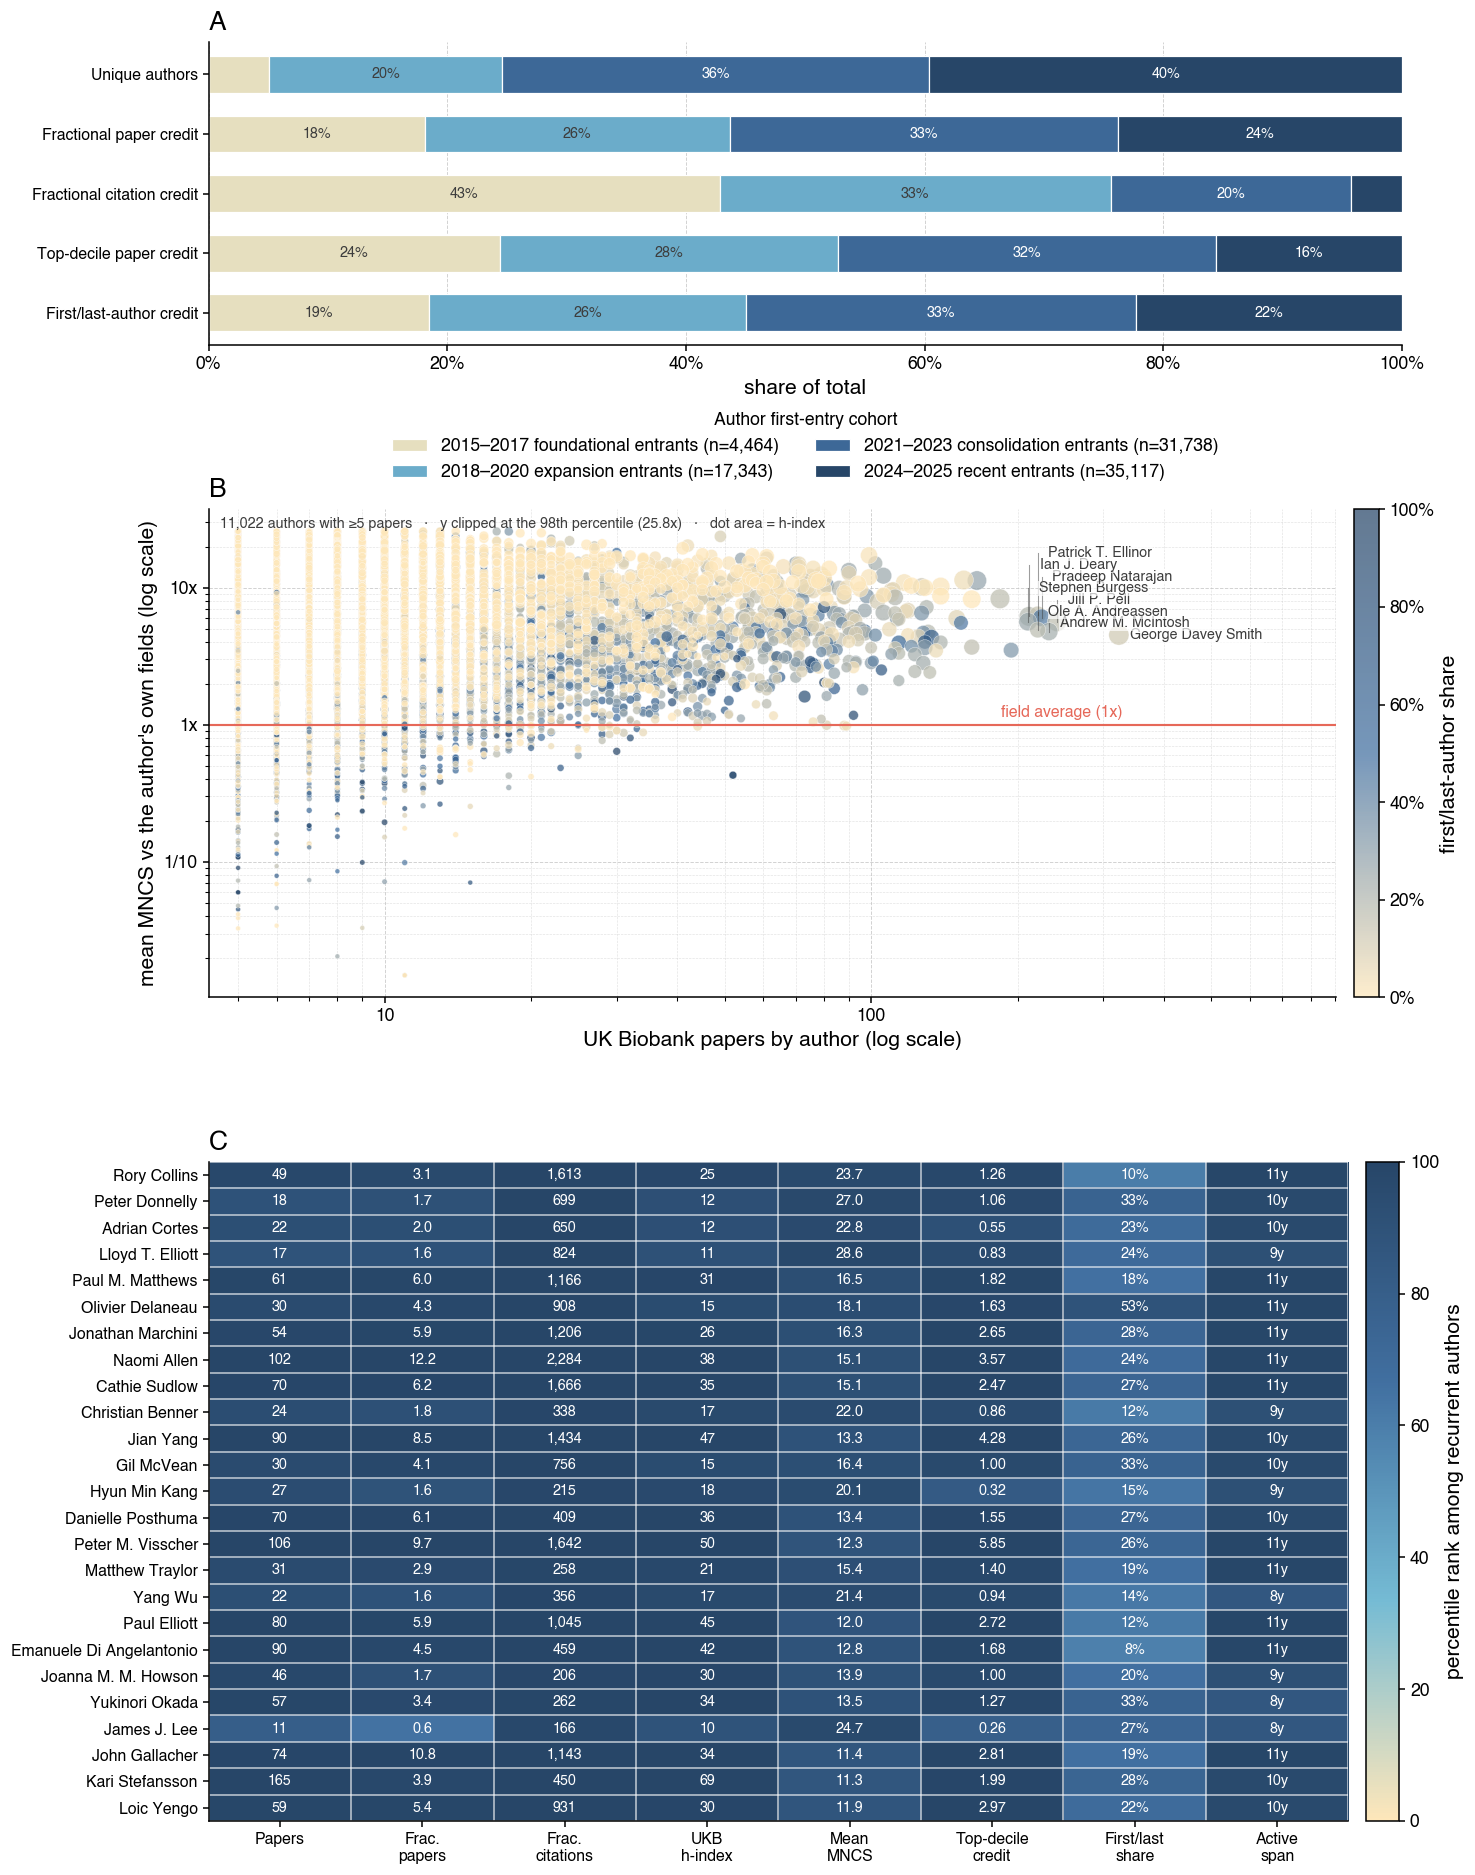

In [9]:
fig_si3 = NP.figure_si_author_arm(D)

## 8. What was written

Every file this notebook produced, with its size, so a re-run can be compared against the
last one rather than trusted. **pdf and png only** — svg was dropped from every style
section on 2026-09-09; the author-arm portfolio panel alone was an 8 MB svg, because each
of its 11,022 authors becomes its own element. The glob follows D30's naming scheme, so the author
notebook's own three figures — which sit in the same directory under their `fig…` stems —
are correctly not listed here.

In [10]:
written = sorted(
    p for p in FIG_DIR.glob("03_[0-9][0-9]_*.*")
    if p.suffix.lower() in {".pdf", ".png"}
)
manifest = pd.DataFrame([
    {"file": P.raw_path(p), "kb": p.stat().st_size // 1024,
     "modified": pd.Timestamp(p.stat().st_mtime, unit="s").round("s")}
    for p in written
])
manifest.to_csv(TABLE_DIR / "panel_manifest.csv", index=False)
print(f"{len(written)} figure files under {P.raw_path(FIG_DIR)} "
      f"({manifest.kb.sum() / 1024:.1f} MB)\n")
display(manifest)

8 figure files under output/figures/data_analysis/03_academic_impact (13.0 MB)



,file,kb,modified
0,output/figures/data_analysis/03_academic_impac...,38,2026-09-09 20:03:33
1,output/figures/data_analysis/03_academic_impac...,3506,2026-09-09 20:03:37
2,output/figures/data_analysis/03_academic_impac...,24,2026-09-09 20:03:38
3,output/figures/data_analysis/03_academic_impac...,895,2026-09-09 20:03:39
4,output/figures/data_analysis/03_academic_impac...,30,2026-09-09 20:03:39
5,output/figures/data_analysis/03_academic_impac...,1669,2026-09-09 20:03:41
6,output/figures/data_analysis/03_academic_impac...,1799,2026-09-09 20:03:45
7,output/figures/data_analysis/03_academic_impac...,5323,2026-09-09 20:03:49
